In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [4]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/10xpbmcNuc/10xpbmcNuc_symbol.h5ad"

In [5]:
path_ref = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

### Step 1: Prep data

In [6]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
adata.var.index = adata.var["gene_id"]
#adata.var.index = adata.var["gene_name"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
#adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

# Prep data for cell2sentence 
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="c2s", organism="Homo Sapiens")

In [7]:
# Read the h5ad file (just to explore columns and variables)
adata_ref = sc.read_h5ad(path_ref)

# Subset to select cell types
adata_ref = adata_ref[adata_ref.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata_ref = adata_ref.copy()

# Remove unmapped genes
adata_ref.var.index = adata_ref.var["gene_id"]
#adata_ref.var.index = adata_ref.var["gene_name"]
adata_ref = adata_ref[:, adata_ref.var.index.notnull()]

# Prep data for geneformer 
#adata_ref = load_and_prep_data(adata= adata_ref, cell_type_col= "broad_type", mode="geneformer")

# Prep data for cell2sentence
adata_ref = load_and_prep_data(adata= adata_ref, cell_type_col= "broad_type", mode="c2s", organism="Homo Sapiens")

In [8]:
adata.obs["broad_type"].value_counts()

broad_type
T cells      4207
Monocytes    3595
B cells       975
NK cells      518
Name: count, dtype: int64

In [9]:
adata_ref.obs["broad_type"].value_counts()

broad_type
B cells      800
Monocytes    800
NK cells     800
T cells      800
Name: count, dtype: int64

### Step 2: Create pseudobulk

In [10]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = generate_pseudobulk(adata = adata,
                                             cell_type_col = "broad_type",
                                             n_pseudobulks = 250,
                                             target_proportion_min = 0.1,
                                             target_proportion_max = 0.80, 
                                             n_cells_per_pseudobulk = 300, 
                                             random_state = 42 
                                            )

### Step 3: Create signature matrix

In [11]:
# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata_ref,
                                  sample_col = "batch", # sample id column
                                  cell_type_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

In [12]:
#pseudo_bulk.to_csv("../scripts/pseudobulk_data_10xpbmcNuc_symbol.csv")

### Step 4: Extract Embeddings

In [13]:
from embeddings import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [14]:
from deconvolution import *

<h4 style="color:blue">Geneformer</h4>

In [15]:
sig_mat_gf_embed = extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    delete_temp_files = True
)

Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████| 1/1 [00:00<00:00, 29.22it/s]

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.



BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    delete_temp_files = True
)

Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████| 1/1 [00:00<00:00,  2.48it/s]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/5 [00:00<?, ?it/s]

In [17]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, 
                            signature_df = sig_mat_gf_embed.T, 
                            normalize = True)

Using 1152 common features.
Running deconvolution...


In [18]:
cell_prop_pred.head()

broad_type,B cells,Monocytes,NK cells,T cells
B cells_PB1,0.302534,0.405527,0.000000,0.291939
B cells_PB2,0.527982,0.255481,0.013112,0.203425
NK cells_PB3,0.312861,0.387005,0.010776,0.289359
T cells_PB4,0.240314,0.469984,0.000000,0.289702
T cells_PB5,0.244842,0.605223,0.000000,0.149935


In [19]:
cell_prop.head()

,T cells,Monocytes,B cells,NK cells
B cells_PB1,0.346667,0.250000,0.363333,0.040000
B cells_PB2,0.136667,0.080000,0.766667,0.016667
NK cells_PB3,0.186667,0.170000,0.030000,0.613333
T cells_PB4,0.520000,0.330000,0.096667,0.053333
T cells_PB5,0.210000,0.566667,0.153333,0.070000


In [20]:
cell_prop_pred.to_csv("../results/pbmc10xNuc/GeneformerL12_estimated_proportions.csv")

In [23]:
#cell_prop.to_csv("../results/pbmc10xNuc/pseudobulk_true_proportions.csv")

<h4 style="color:blue">PCA</h4>

In [24]:
# Extract embeddings 
bulk_sig_mat_pc = extract_components(bulk_df = pseudo_bulk,
                                     sig_mat = sig_mat,
                                     mode = "pca",
                                     transform = True)

bulk_pc = bulk_sig_mat_pc["pca_bulk"]
sig_mat_pc = bulk_sig_mat_pc["sig_pca"]

Variance explained by 4 PCs: 100.00%


In [25]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = bulk_pc.T, 
                            signature_df = sig_mat_pc.T, 
                            normalize = True)

Using 4 common features.
Running deconvolution...


In [27]:
#cell_prop_pred.to_csv("../results/pbmc10xNuc/PCA_estimated_proportions.csv")

<h4 style="color:blue">scVI</h4>

In [28]:
sig_mat_scvi_embed = extract_embs(
    bulk_df = sig_mat, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 44.262499999999996% reference vars in query data.                                                   
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


In [29]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 63.5% reference vars in query data.                                                                 
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


In [30]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_scvi_embed.T, 
                            normalize = True)

Using 50 common features.
Running deconvolution...


In [32]:
#cell_prop_pred.to_csv("../results/pbmc10xNuc/scVI_estimated_proportions.csv")

<h4 style="color:blue">Counts</h4>

In [33]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk.T,
                            signature_df = sig_mat.T,
                            normalize = True)

Using 22525 common features.
Running deconvolution...


In [35]:
#cell_prop_pred.to_csv("../results/pbmc10xNuc/Counts_estimated_proportions.csv")

<h4 style="color:blue">scGPT</h4>

In [20]:
sig_mat_scgpt_embed = extract_embs(
    bulk_df = sig_mat, 
    mode = "scgpt", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/scGPT-0.2.4/models/scGPT_human",
    delete_temp_files = True 
)

scGPT - INFO - match 18170/22982 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 1/1 [00:00<00:00,  2.46it/s]


In [21]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk,
    mode = "scgpt", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/scGPT-0.2.4/models/scGPT_human",
    delete_temp_files = True 
)

scGPT - INFO - match 24282/36581 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 4/4 [00:00<00:00,  5.78it/s]


In [22]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, 
                            signature_df = sig_mat_scgpt_embed.T,
                            normalize = True)

Using 512 common features.
Running deconvolution...


In [23]:
cell_prop_pred.to_csv("../results/pbmc10xNuc/scGPT_estimated_proportions.csv")

<h4 style="color:blue">Cell2Sentence</h4>

In [16]:
sig_mat_c2s_embed = extract_embs(
    bulk_df = sig_mat, 
    mode = "c2s", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/C2S-Pythia-410m-cell-type-prediction/", 
    delete_temp_files = True
)

In [18]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "c2s",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/C2S-Pythia-410m-cell-type-prediction/", 
    delete_temp_files = True
)

WARN: more variables (32391) than observations (250)... did you mean to transpose the object (e.g. adata.T)?
WARN: more variables (32391) than observations (250), did you mean to transpose the object (e.g. adata.T)?
100%|██████████| 250/250 [00:00<00:00, 539.99it/s]


Saving the dataset (0/1 shards):   0%|          | 0/250 [00:00<?, ? examples/s]

Using device: cuda
Reloading model from path on disk: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/c2s_model
Embedding 250 cells using CSModel...


100%|██████████| 250/250 [00:02<00:00, 84.38it/s]


In [20]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_c2s_embed.T, 
                            normalize = True)

Using 1024 common features.
Running deconvolution...


In [21]:
cell_prop_pred.to_csv("../results/pbmc10xNuc/C2S_estimated_proportions.csv")

<h4 style="color:blue">CellHermes</h4>

In [18]:
# sig_mat_ch_embed = extract_embs(
#     bulk_df = sig_mat, 
#     mode = "cellhermes", 
#     temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
#     model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes", 
#     delete_temp_files = True)

In [17]:
# pseudo_bulk_embed = extract_embs(
#     bulk_df = pseudo_bulk, 
#     mode = "cellhermes",
#     temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
#     model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes", 
#     delete_temp_files = True
# )

In [19]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_ch_embed.T, 
                            normalize = True)

Using 4096 common features.
Running deconvolution...


In [20]:
cell_prop_pred.to_csv("../results/pbmc10xNuc/CellHermes_estimated_proportions.csv")

### Step 5: Visualize Results

In [21]:
# Import associated modules
from visualization import *

In [22]:
res_df = load_results(folder_path = '../results/pbmc10xNuc/',
                      ground_truth_file = '../results/pbmc10xNuc/pseudobulk_true_proportions.csv')

# Drop ground truth results 
res_df = res_df[res_df.Model != "pseudobulk"]

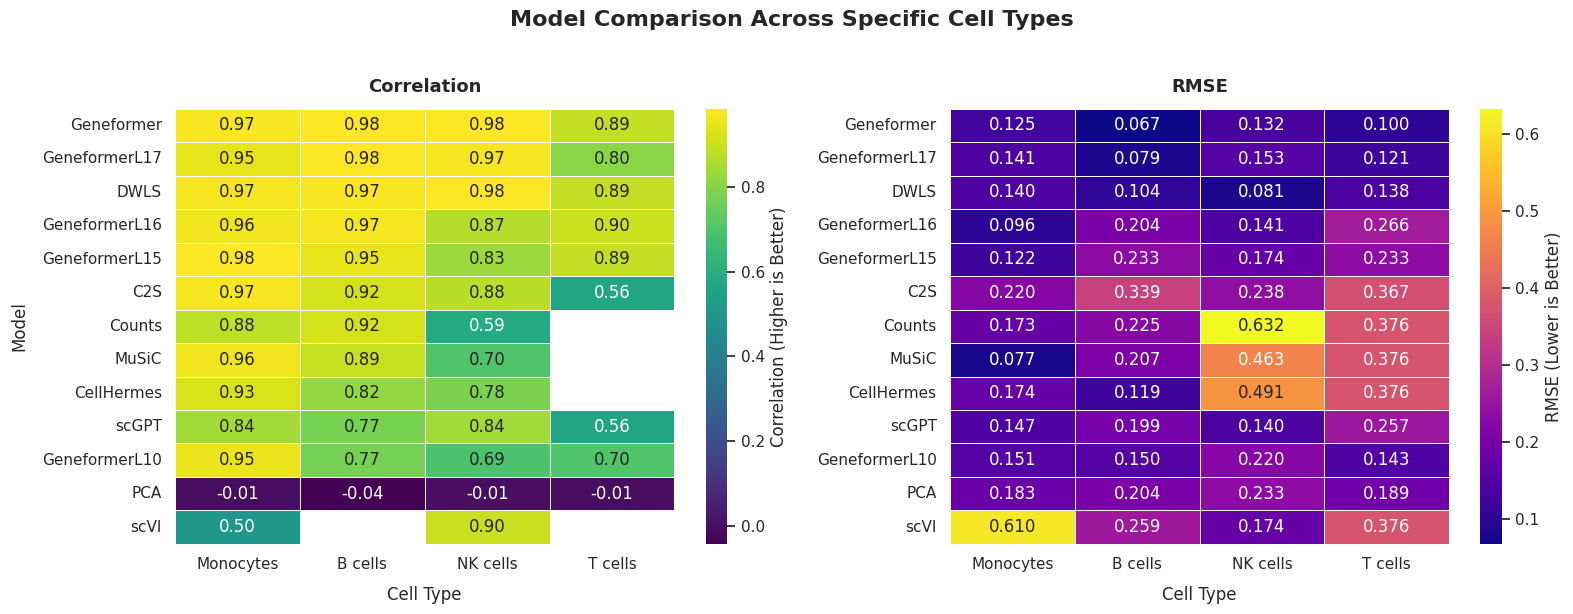

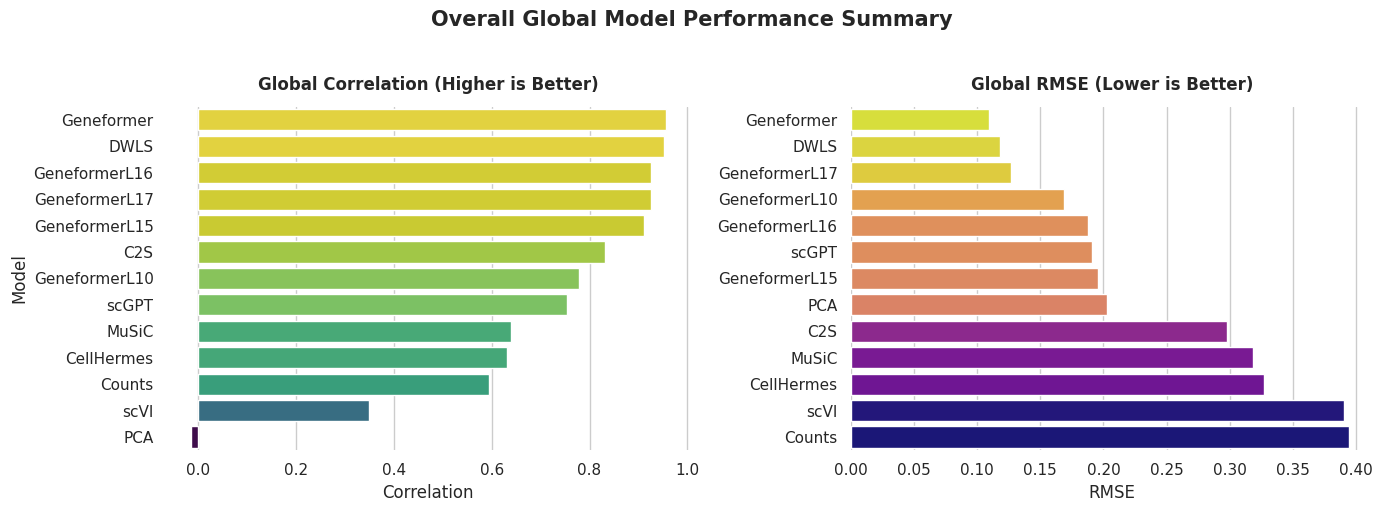

In [23]:
# Remove global correlations/RMSEs
res_df_cell_type = res_df[res_df['CellType'] != 'Global'].copy()
res_df_global = res_df[res_df['CellType'] == 'Global'].copy()

# Plot
plot_cell_type_heatmaps(res_df_cell_type)
plot_global_comparison(res_df_global)